In [2]:
import h5py
import tabulate
import contextily as ctx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import random
import math
from datetime import datetime, timedelta
from os import path
from shapely.geometry import Point
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.colors import ListedColormap
from scipy import stats
import time
import multiprocessing
from multiprocessing import Pool
from rasterio.plot import show
import functools
from osgeo import ogr
from osgeo import gdal
import os
from glob import glob
from os import path
%matplotlib inline

## Step 1 loading training datasets

In [11]:
cwd='EA_FR_data'  

In [15]:
tile_l24_tr = =pd.read_csv(cwd+'/data/demo_data/tile167065_l24a_all_topo_ls_lhs_nbr_dur8.csv')

/home/liangm/.conda/envs/ea_work/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3186: DtypeWarning: Columns (156) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [18]:
# basic GEDI quality filter
tile_l24_tr['agbd']  = tile_l24_tr['agbd_x']
tile_l24_tr['lon_lowestmode']  = tile_l24_tr['lon_lowestmode_x']
tile_l24_tr['lat_lowestmode']  = tile_l24_tr['lat_lowestmode_x']
tile_l24_tr=  tile_l24_tr.loc[(tile_l24_tr['l2a_quality_flag']==1) &
                                    (tile_l24_tr['l2b_quality_flag']==1) &
                                    (tile_l24_tr['geolocation_degrade_flag']==0) &
                          (tile_l24_tr['l4_quality_flag']==1) & tile_l24_tr['agbd'].notnull()]
tile_l24_tr.shape

(798770, 286)

<AxesSubplot:>

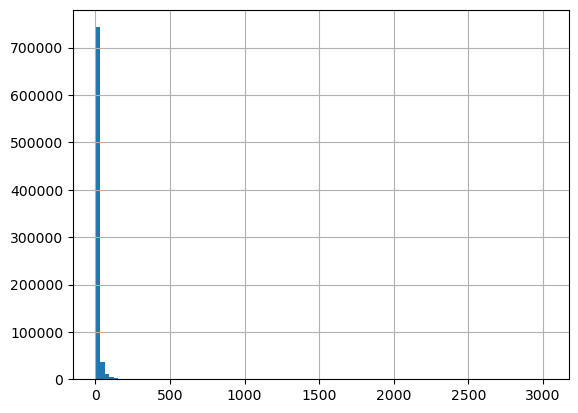

In [19]:
#check GEDI AGBD distribution
tile_l24_tr.agbd.hist(bins=100)

In [22]:
# create a simpler training dataset with selected Landsat predictors and relevent GEDI parameters
ls_vars=['GDDUR','GDMAG','GDRCH','GDROC','GDTSS','GDTSE','ftv_b1_fit_contrast','ftv_b1_fit_diss','ftv_b1_fit_savg',
         'ftv_b1_fit_idm','ftv_b1_fit_asm','ftv_b1_fit_ent', 'ftv_b1_fit_var','ftv_b1_fit_corr','ftv_b2_fit_contrast',
         'ftv_b2_fit_diss','ftv_b2_fit_savg','ftv_b2_fit_idm','ftv_b2_fit_asm', 'ftv_b2_fit_ent','ftv_b2_fit_var',
         'ftv_b2_fit_corr','ftv_b3_fit_contrast','ftv_b3_fit_diss','ftv_b3_fit_savg','ftv_b3_fit_idm','ftv_b3_fit_asm',
         'ftv_b3_fit_ent','ftv_b3_fit_var','ftv_b3_fit_corr','ftv_b4_fit_contrast','ftv_b4_fit_diss','ftv_b4_fit_savg',
         'ftv_b4_fit_idm','ftv_b4_fit_asm','ftv_b4_fit_ent','ftv_b4_fit_var' ,'ftv_b4_fit_corr', 'ftv_b5_fit_contrast',
         'ftv_b5_fit_diss','ftv_b5_fit_savg','ftv_b5_fit_idm','ftv_b5_fit_asm', 'ftv_b5_fit_ent','ftv_b5_fit_var', 
         'ftv_b5_fit_corr','ftv_b7_fit_contrast','ftv_b7_fit_diss','ftv_b7_fit_savg','ftv_b7_fit_idm','ftv_b7_fit_asm',
         'ftv_b7_fit_ent','ftv_b7_fit_var','ftv_b7_fit_corr','GV','Shade','NPV', 'Soil','NDFI','ftv_nbr_fit',
         'ftv_ndfi_fit','ftv_ndvi_fit','ftv_evi_fit', 'ftv_ndmi_fit','ftv_ndsi_fit',
         'ftv_b1_fit','ftv_b2_fit','ftv_b3_fit','ftv_b4_fit','ftv_b5_fit','ftv_b7_fit','ftv_tcw_fit', 'ftv_tcb_fit',
         'ftv_tcg_fit', 'ftv_tca_fit',
          'ADDUR','ADMAG','ADVAL','ADROC','ADVA5', 'ADMG5','ADRE5','ADRE',
          'BDDUR','BDMAG','BDVAL','BDROC','CTROC','LMDUR','LMMAG','LMROC',
          'slope', 'aspect','dem','lon_lowestmode', 'lat_lowestmode']

print(len(ls_vars))
gedi_vars = ['agbd','agbd_se','sensitivity_x','BEAM','rh100', 'cover','pai','selected_algorithm','solar_elevation']
subset_vars= ls_vars+gedi_vars
subset_df = tile_l24_tr[subset_vars]
print(subset_df.shape)
subset_df_cov = subset_df[subset_df['sensitivity_x']>= 0.97]
print(subset_df_cov.shape)
subset_df_cov['ftv_ndvi_fit']=subset_df_cov['ftv_ndvi_fit']/1000
subset_df_dif = subset_df_cov['cover']-subset_df_cov['ftv_ndvi_fit']
sd =abs(subset_df_dif.std())
sig1= abs(subset_df_dif)<= sd
sigHalf=abs(subset_df_dif)<= abs(sd)*0.5
sigOneHalf=abs(subset_df_dif)<= abs(sd)*1.5
sig2=abs(subset_df_dif)<= abs(sd)*2

subset_df_cov['ndvi_cov_diff']=subset_df_dif
subset_df_cov['onesig_diff']= sig1
subset_df_cov['halfsig_diff']= sigHalf
subset_df_cov['onehalfSig_diff']= sigOneHalf
subset_df_cov['twosig_diff']= sig2

#testing model performance's response to different GEDI filtering
subset_df_geo = subset_df_cov[subset_df_cov['twosig_diff']==True]
subset_df_geo =subset_df_geo[subset_df_geo['solar_elevation']<0]
subset_df_geo =subset_df_geo[subset_df_geo['BEAM'].isin(['BEAM1000', 'BEAM0101', 'BEAM0110', 'BEAM1011'])]
print(subset_df_geo.shape)

96
(798770, 105)
(241884, 105)
(53074, 110)


/home/liangm/.conda/envs/ea_work/lib/python3.7/site-packages/ipykernel_launcher.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/liangm/.conda/envs/ea_work/lib/python3.7/site-packages/ipykernel_launcher.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/liangm/.conda/envs/ea_work/lib/python3.7/site-packages/ipykernel_launcher.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

In [23]:
# train-test split and transform GEDI AGBD
subset_df_geo['sqrt_agbd']=  np.sqrt(subset_df_geo['agbd'])
subset_df_geo['log_agbd']=  np.log(subset_df_geo['agbd'])
samp_df_geo = subset_df_geo.sample(frac=0.8, replace=False, random_state=1)
pdf = samp_df_geo[ls_vars]  #dataframe with only predictor vars
print(pdf.isnull().values.any())  #check if any predictor has nan values

False


GV              0.713716
Shade           0.528019
NDFI            0.754986
ftv_nbr_fit     0.734757
ftv_ndfi_fit    0.761432
ftv_ndvi_fit    0.803500
ftv_evi_fit     0.498254
ftv_ndmi_fit    0.713780
ftv_tcw_fit     0.653767
ftv_tcg_fit     0.643102
ftv_tca_fit     0.804150
slope           0.651766
dem             0.534339
sqrt_agbd       1.000000
Name: sqrt_agbd, dtype: float64

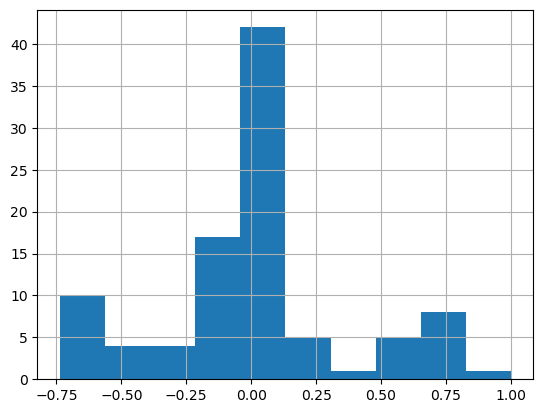

In [24]:
###----check the corelation coefficients between ls_metrics and the agbd of different transformation-----
sdf= samp_df_geo[ls_vars+['sqrt_agbd']]
correlations = sdf.corr()
correlations.sqrt_agbd.hist()
correlations[correlations['sqrt_agbd']>=0.4].sqrt_agbd

(42459, 97)


GV              0.677147
Shade           0.562280
NDFI            0.733115
ftv_nbr_fit     0.668517
ftv_ndfi_fit    0.738253
ftv_ndvi_fit    0.768867
ftv_evi_fit     0.456468
ftv_ndmi_fit    0.632353
ftv_tcw_fit     0.663172
ftv_tcg_fit     0.599574
ftv_tca_fit     0.749038
slope           0.509354
dem             0.484701
log_agbd        1.000000
Name: log_agbd, dtype: float64

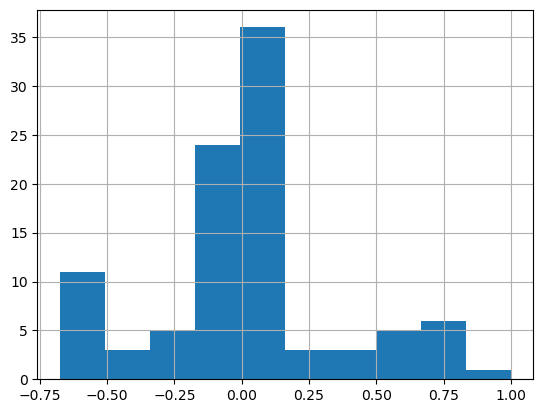

In [25]:
ldf= samp_df_geo[ls_vars+['log_agbd']]
print(ldf.shape)
correlations = ldf.corr()
correlations.log_agbd.hist()
correlations[correlations['log_agbd']>=0.4].log_agbd
# print(correlations.log_agbd)

## Step 2 XGBoost model with sqrt-tranformed AGBD

In [26]:
import xgboost as xgb
from sklearn.datasets import load_boston
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
import pylab
from sklearn import set_config 
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr


In [27]:
#set up naming for exports
trans_agbd = 'sqrt'
pheno='lhs'
tile='aoi'
pattern ='xgboost_'+trans_agbd+'_nbr_'+pheno+'_'+tile+'_beam+sol'
print(pattern)
mOut='data/mod_fig/'

if trans_agbd!='sqrt':
    print('log trans')
    ldf_v=ldf.values
    x= ldf.iloc [:, : -1].values
    y =  ldf.iloc [:, -1 :].values
else:
    print('sqrt trans')
    sdf_v=sdf.values
    x= sdf.iloc [:, : -1].values
    y =  sdf.iloc [:, -1 :].values
print(type(y))
print(y)


X_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=1)
print(X_train.shape)
print(type(X_train))


#define function for back transformation that corresponds to the transformation for response var 
def back_trans(x):
    x = np.squeeze(x)
    if trans_agbd == 'sqrt':
        return np.square(x)
    else:
        return np.exp(x)

def get_r2(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    r_squared = 1 - (sum((y - (slope * x + intercept))**2) / ((len(y) - 1) * np.var(y, ddof=1)))
    return r_squared

def model_performance(ytest, yhat, xtest, save = None ):
    ytest=np.squeeze(ytest)
    yhat =np.squeeze(yhat)

    r20= get_r2(ytest, yhat)    
    mae0 = mean_absolute_error(ytest, yhat)
#     rmse0= mse0**(1/2.0)

    mse = mean_squared_error(back_trans(ytest), back_trans(yhat))
    rmse= mse**(1/2.0)
    r2= get_r2(back_trans(ytest), back_trans(yhat))
    adjR2= (1-(1-r2)*((len(xtest)-1)/(len(xtest)-xtest.shape[1]-1)))
    corr, _ = pearsonr(back_trans(ytest), back_trans(yhat))

    rmspe =  rmse/(back_trans(ytest).mean())*100
    bias = (back_trans(ytest).mean())- (back_trans(yhat).mean())
    
    mae =  mean_absolute_error(back_trans(ytest), back_trans(yhat))

    # Calculate the point density
    x2 = back_trans(ytest)
    y2= back_trans(yhat)
    xy = np.vstack([x2,y2])
    z = gaussian_kde(xy)(xy)

    # Sort the points by density, so that the densest points are plotted last
    idx = z.argsort()
    x2, y2, z = x2[idx], y2[idx], z[idx]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x2, y2, c=z, s=40)
    p1 = max(max(y2), max(x2))
    p2 = min(min(y2), min(x2))
    plt.plot([p1, p2], [p1, p2], 'b-')
    plt.ylim([0,800])
    plt.xlim([0,800])
    
    pylab.text(0.02, 0.78, 'r2 %.2f' % r2 +',  ' + 'adj r2 %.2f' % adjR2 +',  ' +'MAE %.2f' % mae +'\n' +
               "MSE: %.2f" % mse +',  ' + "RMSE: %.2f" % (mse**(1/2.0))+ ',  ' + "r: %.2f" % corr+ '\n'+
               "rmspe: %.2f" % rmspe +',  ' +"bias: %.2f" % bias +'\n'+
               "r2_trans: %.2f" % r20 +',  ' + "MAE_trans: %.2f" % mae0 +'\n'+ "n= {:,}".format(ytest.shape[0]), 
               transform=ax.transAxes, fontsize = 13)
    plt.title(pattern.replace("_", " ") +" model performance")
    plt.xlabel("GEDI AGBD (Mg/ha)")
    plt.ylabel("Model predicted AGBD (Mg/ha)")
    
    if save is not None:
        print('saving fig')
        plt.savefig(mOut+pattern+"_"+save+".png", bbox_inches='tight')
    else:
        plt.show()

    
#XGBoost hyper-parameter tuning
def hyperParameterTuning(Xtrain, ytrain, model):
    param_tuning = {
        'learning_rate': [0.01,0.05, 0.1],
        'max_depth': [ 5, 7, 10],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.3, 0.5, 0.7],
        'colsample_bytree': [0.5, 0.7],
        'n_estimators' : [200, 500, 800],
        'objective': ['reg:squarederror']
    }

    xgb_model = model  #this is candiate model 

    gsearch = RandomizedSearchCV(estimator = xgb_model,
                           param_distributions= param_tuning,                        
                           #scoring = 'neg_mean_absolute_error', #MAE
                           #scoring = 'neg_mean_squared_error',  #MSE
                           cv = 5,
                           n_jobs = -1,
                           verbose = 1)

    gsearch.fit(Xtrain,ytrain)

    return gsearch.best_params_

def dcoll(tind, features,  save = None ):
    svi = tind
    select_vars= features
    select_x= x[:, svi] #x[:, selection.get_support()]
    print(select_x.shape)
    select_x_df = pd.DataFrame(data=select_x[0:,0:],    # values
                               index = select_x[0:,0], # 1st column as index
                               columns=select_vars)
    print(select_x_df.shape)
    #--------------dropping highly correlated features---------------------------
    # Create correlation matrix
    corr_matrix = select_x_df.corr().abs()

    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

    # Find features with correlation greater than 0.90
    to_drop = np.array([column for column in upper.columns if any(upper[column] > 0.90)])
    # print(type(to_drop))
    print("dropping covars:", to_drop)
    # to_drop.remove('ftv_tcb_fit')
    td= np.where(np.isin(select_x_df.columns,to_drop))
    td_bool = np.array([True for i in range(select_x_df.shape[1])])
    # print(td_bool[td])
    td_bool[td]=False
    # print(td_bool)
    print('remaining number of vars', len(select_vars[td_bool]), select_vars[td_bool])
    #get the index of the the to-drop features
    coll_rm=xgb.XGBRegressor(colsample_bytree= 0.7,
             learning_rate= 0.01,
             max_depth= 10,
             min_child_weight= 3,
             n_estimators= 800,
             subsample= 0.7)
    coll_rm.fit(X_train[:, svi][:, td_bool], y_train)

    y_hat = coll_rm.predict(x_test[:, svi][:, td_bool])
    if save is not None:
        print('saving fig')
        model_performance(y_test, y_hat, x_test[:, svi][:, td_bool], save=save)
    else:
        model_performance(y_test, y_hat, x_test[:, svi][:, td_bool])
    
    c0 = np.average(back_trans(y_train))/np.average(back_trans(y_hat))
    print('correction factor is:'+str(c0))
    return c0
    

xgboost_sqrt_nbr_lhs_aoi_beam+sol
sqrt trans
<class 'numpy.ndarray'>
[[0.98506361]
 [0.93311997]
 [1.0110278 ]
 ...
 [1.12780407]
 [3.68418011]
 [1.12780407]]
(33967, 96)
<class 'numpy.ndarray'>


### Basic model 

In [28]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

correction factor is:1.1541060835283647


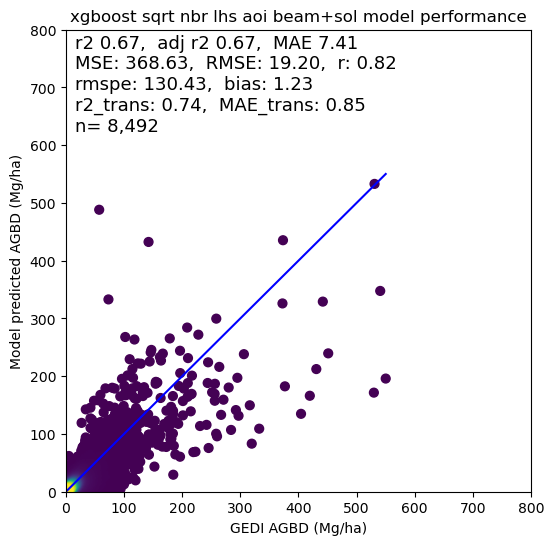

In [29]:
rfr = xgb.XGBRegressor()
rfr.fit(X_train, y_train)   #Note this is just using the untuned model
y_hat =rfr.predict(x_test)

#calculating the correction fcator C for transformed data 
C = np.average(back_trans(y_train))/np.average(back_trans(y_hat))
print('correction factor is:'+str(C))

model_performance(y_test, y_hat, x_test,save=None)
#, save='default_model'

['GDDUR' 'GDMAG' 'GDRCH' 'GDROC' 'GDTSS' 'GDTSE' 'ftv_b1_fit_contrast'
 'ftv_b1_fit_diss' 'ftv_b1_fit_savg' 'ftv_b1_fit_idm' 'ftv_b1_fit_asm'
 'ftv_b1_fit_ent' 'ftv_b1_fit_var' 'ftv_b1_fit_corr' 'ftv_b2_fit_contrast'
 'ftv_b2_fit_diss' 'ftv_b2_fit_savg' 'ftv_b2_fit_idm' 'ftv_b2_fit_asm'
 'ftv_b2_fit_ent' 'ftv_b2_fit_var' 'ftv_b2_fit_corr' 'ftv_b3_fit_contrast'
 'ftv_b3_fit_diss' 'ftv_b3_fit_savg' 'ftv_b3_fit_idm' 'ftv_b3_fit_asm'
 'ftv_b3_fit_ent' 'ftv_b3_fit_var' 'ftv_b3_fit_corr' 'ftv_b4_fit_contrast'
 'ftv_b4_fit_diss' 'ftv_b4_fit_savg' 'ftv_b4_fit_idm' 'ftv_b4_fit_asm'
 'ftv_b4_fit_ent' 'ftv_b4_fit_var' 'ftv_b4_fit_corr' 'ftv_b5_fit_contrast'
 'ftv_b5_fit_diss' 'ftv_b5_fit_savg' 'ftv_b5_fit_idm' 'ftv_b5_fit_asm'
 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b5_fit_corr' 'ftv_b7_fit_contrast'
 'ftv_b7_fit_diss' 'ftv_b7_fit_savg' 'ftv_b7_fit_idm' 'ftv_b7_fit_asm'
 'ftv_b7_fit_ent' 'ftv_b7_fit_var' 'ftv_b7_fit_corr' 'GV' 'Shade' 'NPV'
 'Soil' 'NDFI' 'ftv_nbr_fit' 'ftv_ndfi_fit' 'ftv_ndvi_fi

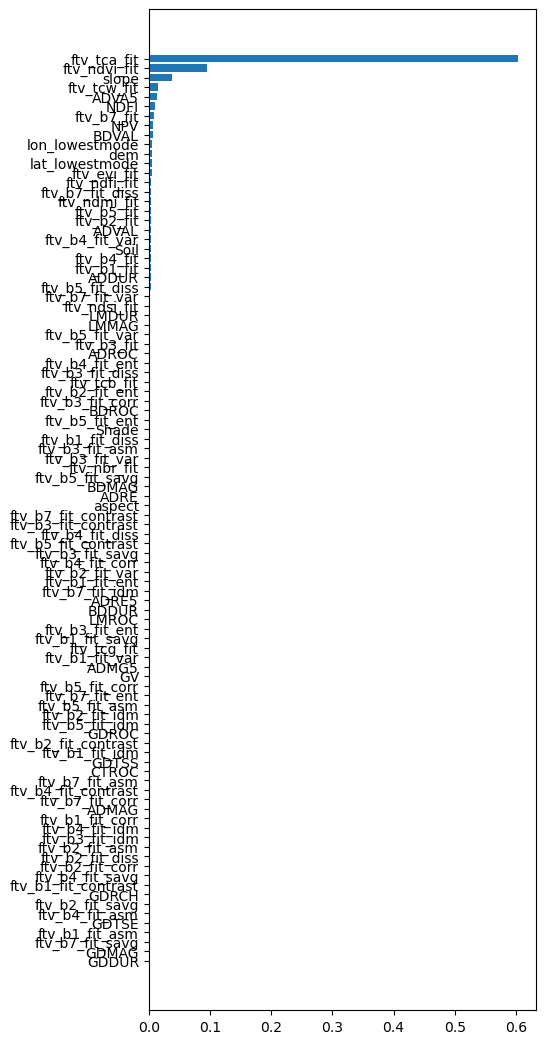

In [30]:
## using the default importance score for feature seletcion
features = np.array(ls_vars)
print(features)
f_i = list(zip(features,rfr.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 13))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])
plt.show()

(42459, 96)
(42459, 96)
dropping covars: ['GDTSS' 'ftv_b1_fit_var' 'ftv_b2_fit_contrast' 'ftv_b2_fit_diss'
 'ftv_b2_fit_savg' 'ftv_b2_fit_asm' 'ftv_b2_fit_ent' 'ftv_b2_fit_var'
 'ftv_b3_fit_contrast' 'ftv_b3_fit_diss' 'ftv_b3_fit_savg'
 'ftv_b3_fit_asm' 'ftv_b3_fit_ent' 'ftv_b3_fit_var' 'ftv_b4_fit_contrast'
 'ftv_b4_fit_asm' 'ftv_b4_fit_ent' 'ftv_b4_fit_var' 'ftv_b5_fit_asm'
 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b7_fit_diss' 'ftv_b7_fit_savg'
 'ftv_b7_fit_asm' 'ftv_b7_fit_ent' 'ftv_b7_fit_var' 'Shade' 'NDFI'
 'ftv_nbr_fit' 'ftv_ndfi_fit' 'ftv_ndvi_fit' 'ftv_ndmi_fit' 'ftv_b1_fit'
 'ftv_b2_fit' 'ftv_b3_fit' 'ftv_b4_fit' 'ftv_b5_fit' 'ftv_b7_fit'
 'ftv_tcw_fit' 'ftv_tcb_fit' 'ftv_tca_fit' 'ADVAL' 'ADROC' 'ADVA5' 'ADMG5'
 'BDDUR' 'BDROC' 'CTROC' 'LMDUR' 'LMMAG' 'LMROC']
remaining number of vars 45 ['GDDUR' 'GDMAG' 'GDRCH' 'GDROC' 'GDTSE' 'ftv_b1_fit_contrast'
 'ftv_b1_fit_diss' 'ftv_b1_fit_savg' 'ftv_b1_fit_idm' 'ftv_b1_fit_asm'
 'ftv_b1_fit_ent' 'ftv_b1_fit_corr' 'ftv_b2_fit_idm' 'ftv

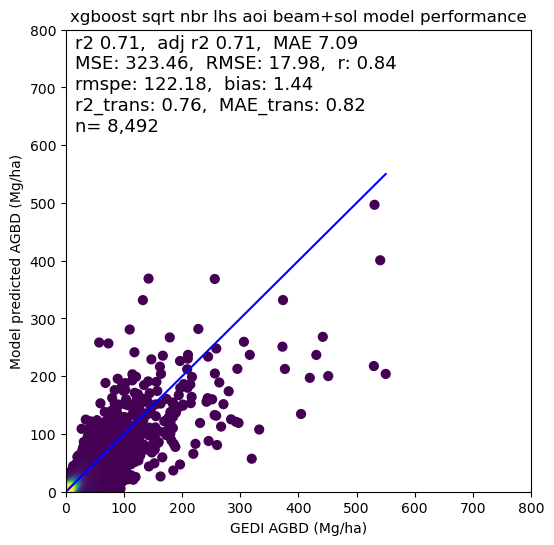

correction factor is:1.1727512123915247


In [31]:
#model with highly correlated predictors removed
C= dcoll(np.where(np.isin(ls_vars,features))[0].tolist(), features,  save = None )

### model (rfr2) with default feature selection

['ftv_ndvi_fit' 'ftv_tcw_fit' 'ftv_tca_fit' 'ADVA5' 'slope']


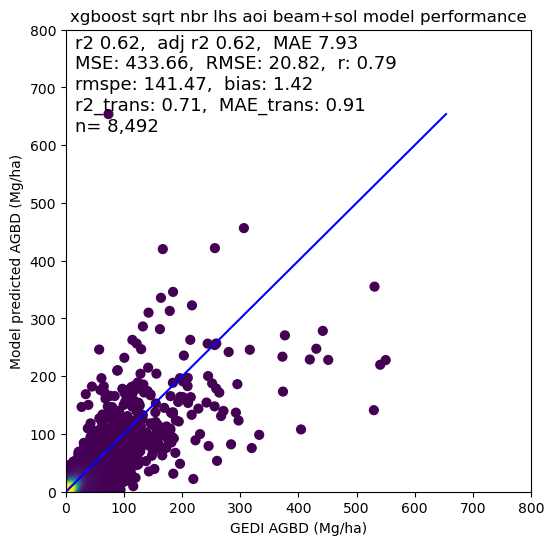

In [32]:
from sklearn.feature_selection import SelectFromModel
rfr1 = SelectFromModel(rfr)
rfr1.fit(X_train, y_train)
rfr1.estimator_.feature_importances_#.ravel()
selected_vars= np.array(ls_vars)[rfr1.get_support()]
print(selected_vars)

rfr2 = xgb.XGBRegressor()
rfr2.fit(X_train[:, rfr1.get_support()], y_train)

ypred = rfr2.predict(x_test[:, rfr1.get_support()])

model_performance(y_test, ypred, x_test[:, rfr1.get_support()],save=None)


['ftv_ndvi_fit' 'ftv_tcw_fit' 'ftv_tca_fit' 'ADVA5' 'slope']


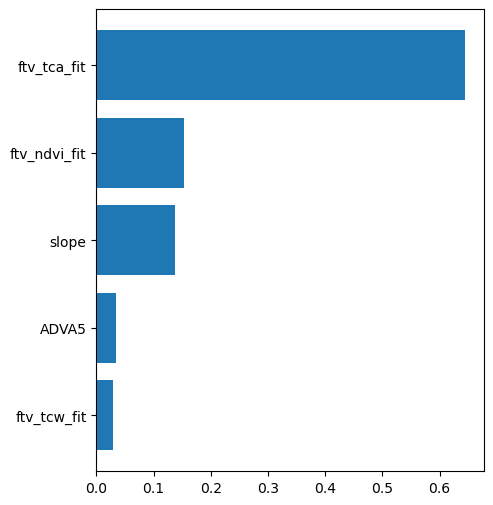

In [33]:
### plot the importance of the variables 
# print("selected vars",np.array(ls_vars)[selection.get_support()])
features =selected_vars# np.array(ls_vars)[rfr2.get_support()]
print(features)
f_i = list(zip(features,rfr2.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 6))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])
plt.show()

(42459, 5)
(42459, 5)
dropping covars: ['ftv_tca_fit' 'ADVA5']
remaining number of vars 3 ['ftv_ndvi_fit' 'ftv_tcw_fit' 'slope']


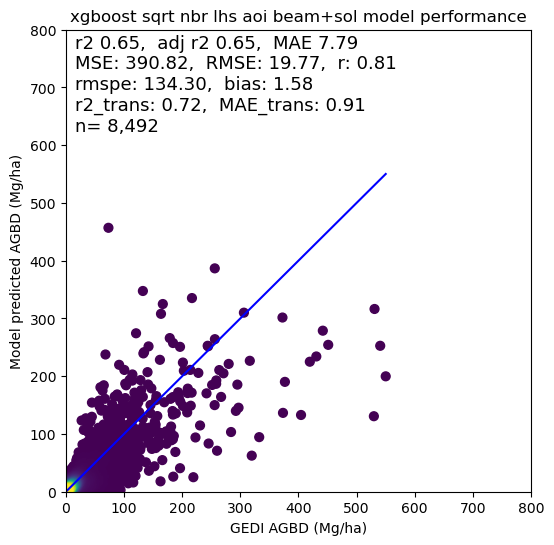

correction factor is:1.1855906414664434


In [34]:
C= dcoll(np.where(np.isin(ls_vars,features))[0].tolist(), features)

### model selection by feature importance

In [35]:
set_config(print_changed_only=False) 
from sklearn.feature_selection import SelectFromModel


In [42]:
### below is by threhsolding the feature importance 
from numpy import sort
thresholds = sort(rfr.feature_importances_)
print(thresholds)

[5.3327496e-04 1.0084886e-03 1.0904896e-03 1.1026456e-03 1.1938065e-03
 1.2164927e-03 1.2304127e-03 1.3026338e-03 1.3899737e-03 1.4244837e-03
 1.4344432e-03 1.4410117e-03 1.4664403e-03 1.4761285e-03 1.6229965e-03
 1.6284907e-03 1.6467730e-03 1.6831602e-03 1.6976775e-03 1.7115771e-03
 1.7129977e-03 1.7310703e-03 1.7341565e-03 1.7441387e-03 1.7455911e-03
 1.7464784e-03 1.7520478e-03 1.7585545e-03 1.7586058e-03 1.7847581e-03
 1.7987848e-03 1.8948934e-03 1.9094163e-03 1.9512294e-03 1.9520891e-03
 1.9569192e-03 1.9998730e-03 2.0110791e-03 2.0256250e-03 2.0537993e-03
 2.0745096e-03 2.0778615e-03 2.0800019e-03 2.1090922e-03 2.1165716e-03
 2.1220150e-03 2.1453237e-03 2.1616661e-03 2.1776729e-03 2.2340710e-03
 2.2453167e-03 2.2461887e-03 2.2478180e-03 2.2542225e-03 2.2840218e-03
 2.3887393e-03 2.4034465e-03 2.4039315e-03 2.4163318e-03 2.4201197e-03
 2.4517213e-03 2.4609275e-03 2.4692719e-03 2.5288139e-03 2.5902125e-03
 2.5926614e-03 2.6045637e-03 2.6427992e-03 2.7449697e-03 2.7694637e-03
 2.839

In [257]:
args = thresholds
def threModel(thresh):  
    selection = SelectFromModel(rfr, threshold=thresh, prefit=True)
    select_X_train = selection.transform(X_train)
    # train model
    selection_model = xgb.XGBRegressor(n_estimators=500, eta=0.05,  subsample=0.5, colsample_bytree=0.5)
    selection_model.fit(select_X_train, y_train)
    # eval model
    select_x_test = selection.transform(x_test)
    predictions = selection_model.predict(select_x_test)
    mae = mean_absolute_error(y_test,predictions)
    print("Thresh=%.4f, n=%d, MAE: %.4f" % (thresh, select_X_train.shape[1], mae))


In [258]:
import multiprocessing
import time

if __name__ == "__main__":
    pool = multiprocessing.Pool(15)
    start_time = time.perf_counter()
    processes = [pool.apply_async(threModel, args=(x,)) for x in thresholds]
    result = [p.get() for p in processes]
    finish_time = time.perf_counter()
    print(f"Program finished in {finish_time-start_time} seconds")
    print(result)

Thresh=0.0016, n=82, MAE: 0.8296
Thresh=0.0015, n=83, MAE: 0.8319
Thresh=0.0015, n=84, MAE: 0.8333
Thresh=0.0014, n=85, MAE: 0.8327
Thresh=0.0014, n=86, MAE: 0.8305
Thresh=0.0014, n=87, MAE: 0.8313
Thresh=0.0013, n=89, MAE: 0.8350
Thresh=0.0014, n=88, MAE: 0.8344
Thresh=0.0012, n=91, MAE: 0.8354
Thresh=0.0012, n=90, MAE: 0.8346
Thresh=0.0011, n=93, MAE: 0.8330
Thresh=0.0012, n=92, MAE: 0.8345
Thresh=0.0010, n=95, MAE: 0.8320
Thresh=0.0011, n=94, MAE: 0.8359
Thresh=0.0005, n=96, MAE: 0.8314
Thresh=0.0018, n=69, MAE: 0.8356
Thresh=0.0018, n=67, MAE: 0.8321
Thresh=0.0017, n=71, MAE: 0.8332
Thresh=0.0017, n=73, MAE: 0.8327
Thresh=0.0018, n=68, MAE: 0.8352
Thresh=0.0017, n=78, MAE: 0.8307
Thresh=0.0017, n=77, MAE: 0.8358
Thresh=0.0017, n=72, MAE: 0.8373
Thresh=0.0017, n=74, MAE: 0.8327
Thresh=0.0017, n=79, MAE: 0.8337
Thresh=0.0017, n=75, MAE: 0.8333
Thresh=0.0016, n=81, MAE: 0.8353
Thresh=0.0016, n=80, MAE: 0.8323
Thresh=0.0017, n=76, MAE: 0.8373
Thresh=0.0021, n=53, MAE: 0.8295
Thresh=0.0

Process ForkPoolWorker-27:
Process ForkPoolWorker-17:
Process ForkPoolWorker-21:
Process ForkPoolWorker-18:
Process ForkPoolWorker-22:
Process ForkPoolWorker-20:
Process ForkPoolWorker-16:
Process ForkPoolWorker-25:
Process ForkPoolWorker-28:
Process ForkPoolWorker-19:
Process ForkPoolWorker-26:
Process ForkPoolWorker-29:
Process ForkPoolWorker-30:
Process ForkPoolWorker-24:
Process ForkPoolWorker-23:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/process.py", line 297, in _bootstr

  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/liangm/.conda/envs/ea_work/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/liangm/

0.0020778615
55
correction factor is:1.1631943026566929


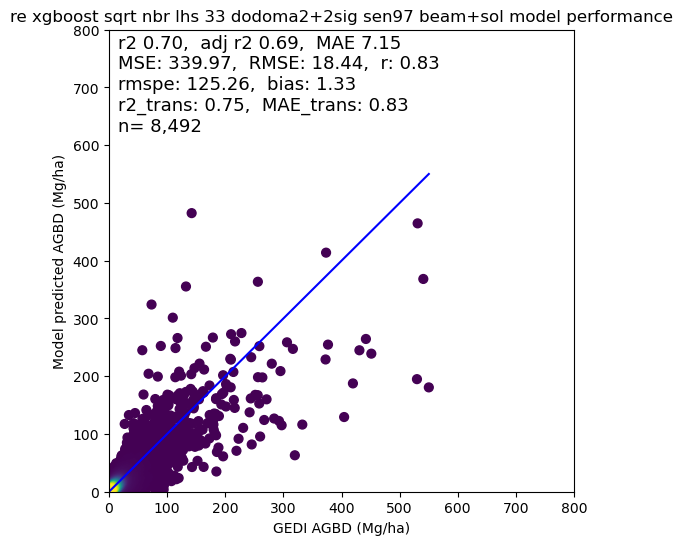

In [43]:
#using the best model from the thresholding procedure identified by the number of predictors
n= 55
thresh = thresholds[96-n]
print(thresh)
selection = SelectFromModel(rfr, threshold=thresh, prefit=True)
select_X_train = selection.transform(X_train)
print(select_X_train.shape[1])
features = np.array(ls_vars)[selection.get_support()]
# train model
selection_model =  xgb.XGBRegressor(objective = 'reg:squarederror',n_estimators=500, eta=0.05,  
                                     subsample=0.5, colsample_bytree=0.5, max_depth = 6, min_child_weight = 1)

selection_model.fit(select_X_train, y_train)
# eval model
select_x_test = selection.transform(x_test)
y_hat =selection_model.predict(select_x_test)

#calculating the correction fcator C for transformed data 
C = np.average(np.square(y_train))/np.average(np.square(y_hat))
print('correction factor is:'+str(C))

model_performance(y_test, y_hat, select_x_test)#, save ='threshodling_model')

In [ ]:
#use these parameters for updating the corresponding models above
hyperParameterTuning(select_X_train, y_train, selection_model)  

['ftv_b1_fit_diss' 'ftv_b2_fit_ent' 'ftv_b2_fit_var' 'ftv_b3_fit_contrast'
 'ftv_b3_fit_diss' 'ftv_b3_fit_savg' 'ftv_b3_fit_asm' 'ftv_b3_fit_var'
 'ftv_b3_fit_corr' 'ftv_b4_fit_diss' 'ftv_b4_fit_ent' 'ftv_b4_fit_var'
 'ftv_b4_fit_corr' 'ftv_b5_fit_contrast' 'ftv_b5_fit_diss'
 'ftv_b5_fit_savg' 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b7_fit_contrast'
 'ftv_b7_fit_diss' 'ftv_b7_fit_var' 'Shade' 'NPV' 'Soil' 'NDFI'
 'ftv_nbr_fit' 'ftv_ndfi_fit' 'ftv_ndvi_fit' 'ftv_evi_fit' 'ftv_ndmi_fit'
 'ftv_ndsi_fit' 'ftv_b1_fit' 'ftv_b2_fit' 'ftv_b3_fit' 'ftv_b4_fit'
 'ftv_b5_fit' 'ftv_b7_fit' 'ftv_tcw_fit' 'ftv_tcb_fit' 'ftv_tca_fit'
 'ADDUR' 'ADVAL' 'ADROC' 'ADVA5' 'ADRE' 'BDMAG' 'BDVAL' 'BDROC' 'LMDUR'
 'LMMAG' 'slope' 'aspect' 'dem' 'lon_lowestmode' 'lat_lowestmode']


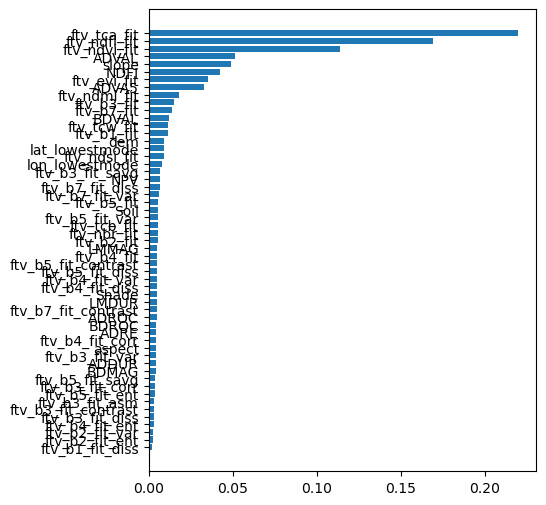

In [44]:
### plot the importance of the variables 
features = np.array(ls_vars)[selection.get_support()]
print(features)
f_i = list(zip(features,selection_model.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 6))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])
plt.show()

(42459, 55)
(42459, 55)
dropping covars: ['ftv_b3_fit_contrast' 'ftv_b3_fit_diss' 'ftv_b3_fit_var' 'ftv_b4_fit_ent'
 'ftv_b4_fit_var' 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b7_fit_diss'
 'ftv_b7_fit_var' 'Shade' 'ftv_nbr_fit' 'ftv_ndfi_fit' 'ftv_ndvi_fit'
 'ftv_ndmi_fit' 'ftv_b2_fit' 'ftv_b3_fit' 'ftv_b5_fit' 'ftv_b7_fit'
 'ftv_tcw_fit' 'ftv_tcb_fit' 'ftv_tca_fit' 'ADVAL' 'ADVA5' 'BDROC']
remaining number of vars 31 ['ftv_b1_fit_diss' 'ftv_b2_fit_ent' 'ftv_b2_fit_var' 'ftv_b3_fit_savg'
 'ftv_b3_fit_asm' 'ftv_b3_fit_corr' 'ftv_b4_fit_diss' 'ftv_b4_fit_corr'
 'ftv_b5_fit_contrast' 'ftv_b5_fit_diss' 'ftv_b5_fit_savg'
 'ftv_b7_fit_contrast' 'NPV' 'Soil' 'NDFI' 'ftv_evi_fit' 'ftv_ndsi_fit'
 'ftv_b1_fit' 'ftv_b4_fit' 'ADDUR' 'ADROC' 'ADRE' 'BDMAG' 'BDVAL' 'LMDUR'
 'LMMAG' 'slope' 'aspect' 'dem' 'lon_lowestmode' 'lat_lowestmode']


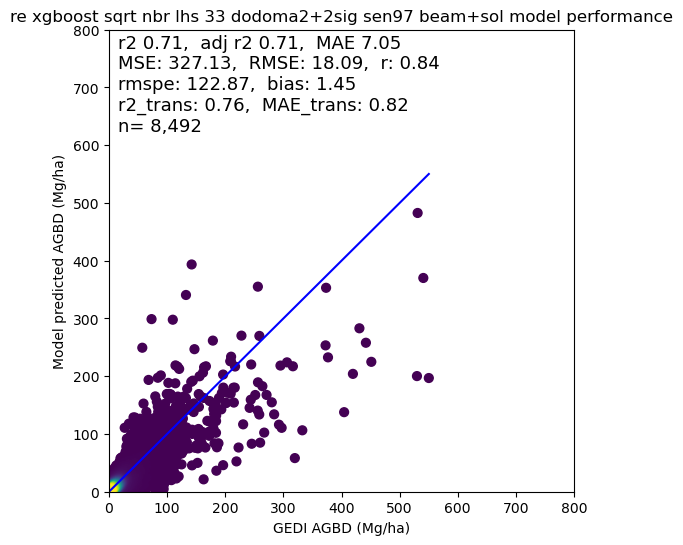

correction factor is:1.1737521279629017


In [45]:
C= dcoll(np.where(np.isin(ls_vars,features))[0].tolist(), features, save =None)

### Explore the different group of Landsat VIs and test model performance for each group 

#### 1) model with Spectral VI + topography

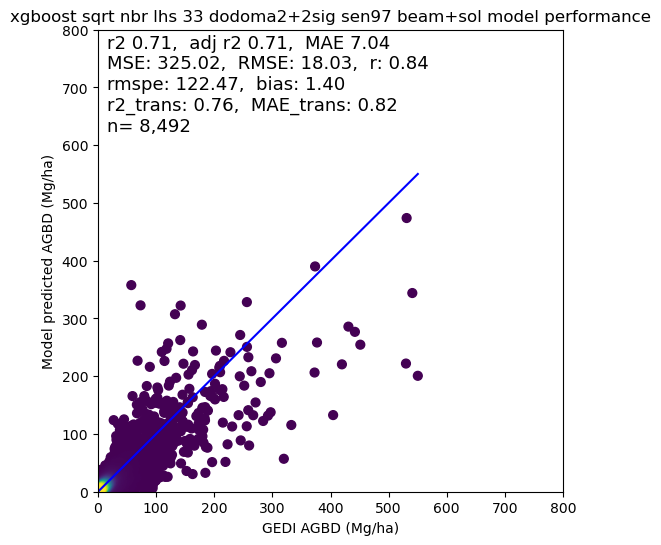

In [262]:
svi =list(range(59,75))+list(range(91,96))
rfr3 =  xgb.XGBRegressor(colsample_bytree= 0.7,
 learning_rate=0.01,
 max_depth= 10,
 min_child_weight= 5,
 n_estimators= 800,
 subsample= 0.7) 

rfr3.fit(X_train[:, svi], y_train)
y_hat = rfr3.predict(x_test[:, svi])
model_performance(y_test, y_hat,x_test[:, svi], save=None)


In [129]:
#use these parameters for updating the corresponding models above
hyperParameterTuning(X_train[:, svi], y_train, rfr3)  

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 10,
 'min_child_weight': 3,
 'n_estimators': 800,
 'objective': 'reg:squarederror',
 'subsample': 0.7}

['ftv_nbr_fit' 'ftv_ndfi_fit' 'ftv_ndvi_fit' 'ftv_evi_fit' 'ftv_ndmi_fit'
 'ftv_ndsi_fit' 'ftv_b1_fit' 'ftv_b2_fit' 'ftv_b3_fit' 'ftv_b4_fit'
 'ftv_b5_fit' 'ftv_b7_fit' 'ftv_tcw_fit' 'ftv_tcb_fit' 'ftv_tcg_fit'
 'ftv_tca_fit' 'slope' 'aspect' 'dem' 'lon_lowestmode' 'lat_lowestmode']


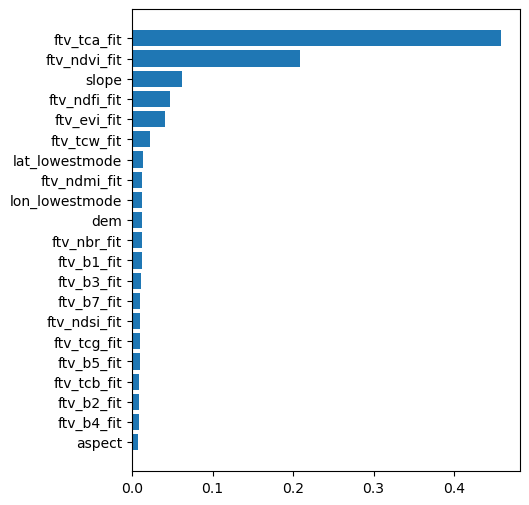

In [265]:
### plot the importance of the variables 
features = np.array(ls_vars)[svi]
print(features)
f_i = list(zip(features,rfr3.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 6))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])
plt.show()

(42459, 21)
(42459, 21)
dropping covars: ['ftv_ndfi_fit' 'ftv_ndvi_fit' 'ftv_ndmi_fit' 'ftv_b2_fit' 'ftv_b3_fit'
 'ftv_b7_fit' 'ftv_tcw_fit' 'ftv_tcb_fit' 'ftv_tca_fit']
remaining number of vars 12 ['ftv_nbr_fit' 'ftv_evi_fit' 'ftv_ndsi_fit' 'ftv_b1_fit' 'ftv_b4_fit'
 'ftv_b5_fit' 'ftv_tcg_fit' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


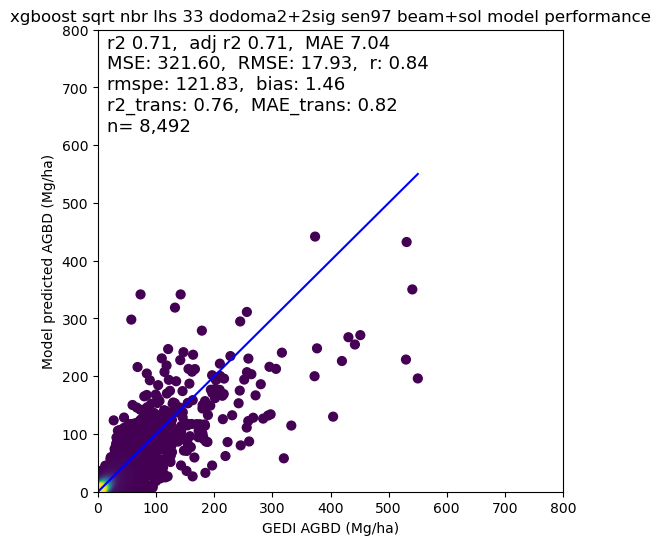

correction factor is:1.1740518748999853


In [264]:
C= dcoll(svi, features,  save = None )

#### 2) model with Spectral Unmixing Coponents + topography

['GV' 'Shade' 'NPV' 'Soil' 'NDFI' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


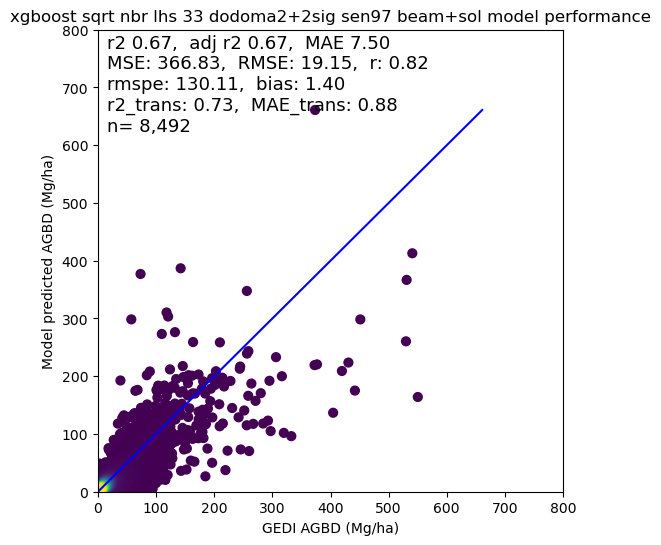

In [266]:
svi = list(range(54,59))+list(range(91,96))
print(np.array(ls_vars)[svi])
rfr4 =  xgb.XGBRegressor() 

rfr4.fit(X_train[:, svi], y_train)
y_hat = rfr4.predict(x_test[:, svi])
r2 = rfr4.score(x_test[:, svi], y_test)
model_performance(y_test, y_hat, x_test[:, svi], save = None)

In [ ]:
#use these parameters for updating the corresponding models above
hyperParameterTuning(X_train[:, svi], y_train, rfr3)  

['GV' 'Shade' 'NPV' 'Soil' 'NDFI' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


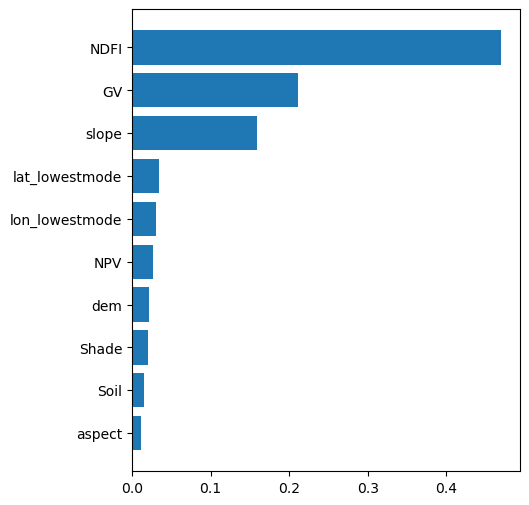

In [267]:
### plot the importance of the variables 
features = np.array(ls_vars)[svi]
print(features)
f_i = list(zip(features,rfr4.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 6))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])
plt.show()

(42459, 10)
(42459, 10)
dropping covars: ['NDFI']
remaining number of vars 9 ['GV' 'Shade' 'NPV' 'Soil' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


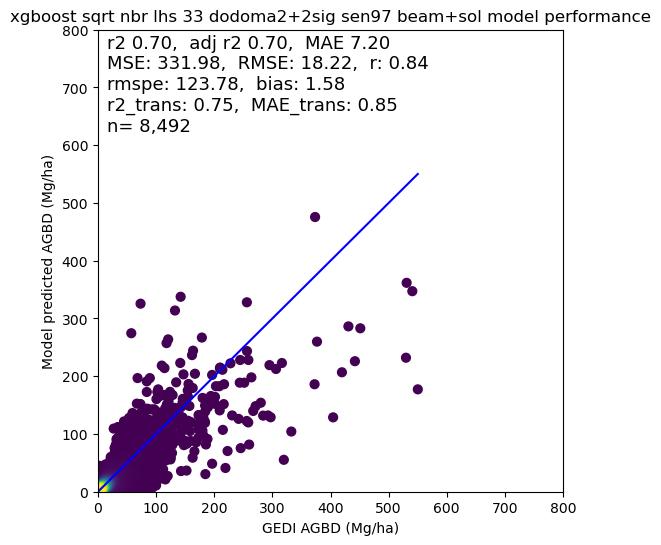

correction factor is:1.185001134419802


In [268]:
C= dcoll(svi, features,  save = None )

#### 3) model with time series change metrics + topography

['GDDUR' 'GDMAG' 'GDRCH' 'GDROC' 'GDTSS' 'GDTSE' 'ADDUR' 'ADMAG' 'ADVAL'
 'ADROC' 'ADVA5' 'ADMG5' 'ADRE5' 'ADRE' 'BDDUR' 'BDMAG' 'BDVAL' 'BDROC'
 'CTROC' 'LMDUR' 'LMMAG' 'LMROC' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


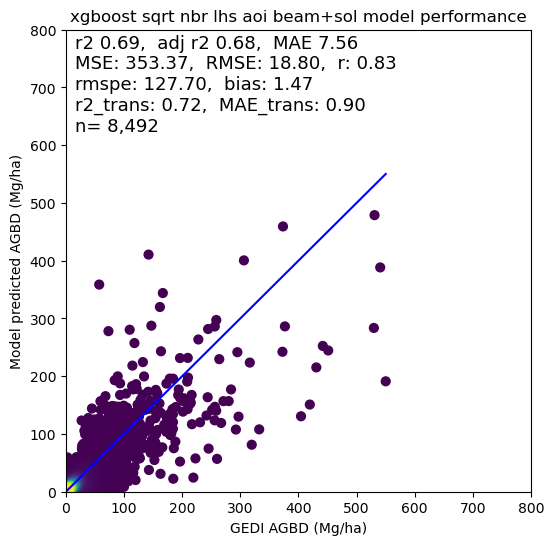

In [36]:
svi = list(range(0,6))+list(range(75,96))
print(np.array(ls_vars)[svi])
rfr5 =  xgb.XGBRegressor() 
rfr5.fit(X_train[:, svi], y_train)
y_hat = rfr5.predict(x_test[:, svi])
model_performance(y_test, y_hat,x_test[:, svi])

In [ ]:
#use these parameters for updating the corresponding models above
hyperParameterTuning(X_train[:, svi], y_train, rfr3)  

['GDDUR' 'GDMAG' 'GDRCH' 'GDROC' 'GDTSS' 'GDTSE' 'ADDUR' 'ADMAG' 'ADVAL'
 'ADROC' 'ADVA5' 'ADMG5' 'ADRE5' 'ADRE' 'BDDUR' 'BDMAG' 'BDVAL' 'BDROC'
 'CTROC' 'LMDUR' 'LMMAG' 'LMROC' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


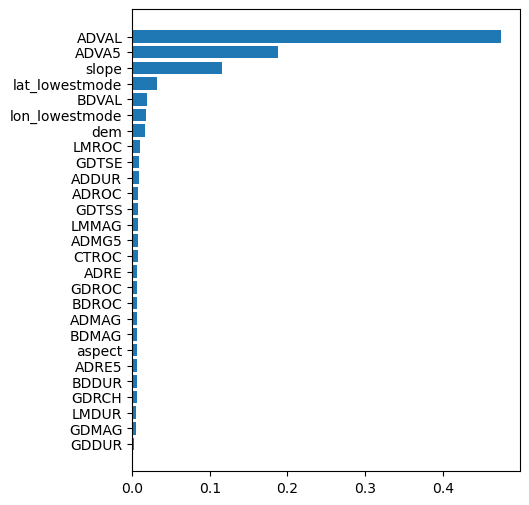

In [37]:
### plot the importance of the variables 
features = np.array(ls_vars)[svi]
print(features)
f_i = list(zip(features,rfr5.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 6))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])
plt.show()

(42459, 27)
(42459, 27)
dropping covars: ['GDTSS' 'ADROC' 'ADVA5' 'ADMG5' 'BDDUR' 'BDROC' 'CTROC' 'LMDUR' 'LMMAG'
 'LMROC']
remaining number of vars 17 ['GDDUR' 'GDMAG' 'GDRCH' 'GDROC' 'GDTSE' 'ADDUR' 'ADMAG' 'ADVAL' 'ADRE5'
 'ADRE' 'BDMAG' 'BDVAL' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowestmode']


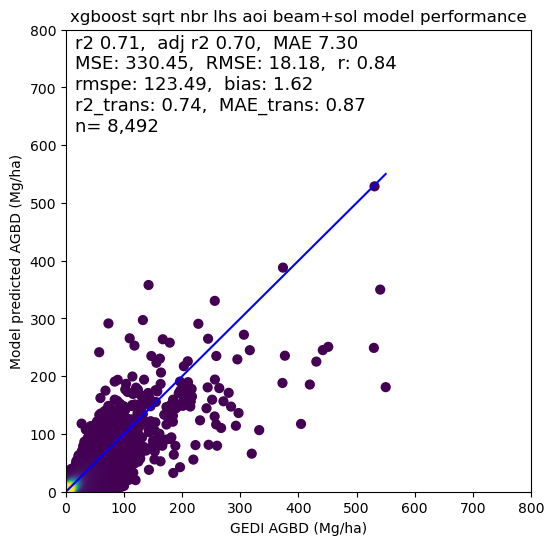

correction factor is:1.189147831167673


In [38]:
C= dcoll(svi, features,  save = None )

#### 4) model with texture metrics + topography

['ftv_b1_fit_contrast' 'ftv_b1_fit_diss' 'ftv_b1_fit_savg'
 'ftv_b1_fit_idm' 'ftv_b1_fit_asm' 'ftv_b1_fit_ent' 'ftv_b1_fit_var'
 'ftv_b1_fit_corr' 'ftv_b2_fit_contrast' 'ftv_b2_fit_diss'
 'ftv_b2_fit_savg' 'ftv_b2_fit_idm' 'ftv_b2_fit_asm' 'ftv_b2_fit_ent'
 'ftv_b2_fit_var' 'ftv_b2_fit_corr' 'ftv_b3_fit_contrast'
 'ftv_b3_fit_diss' 'ftv_b3_fit_savg' 'ftv_b3_fit_idm' 'ftv_b3_fit_asm'
 'ftv_b3_fit_ent' 'ftv_b3_fit_var' 'ftv_b3_fit_corr' 'ftv_b4_fit_contrast'
 'ftv_b4_fit_diss' 'ftv_b4_fit_savg' 'ftv_b4_fit_idm' 'ftv_b4_fit_asm'
 'ftv_b4_fit_ent' 'ftv_b4_fit_var' 'ftv_b4_fit_corr' 'ftv_b5_fit_contrast'
 'ftv_b5_fit_diss' 'ftv_b5_fit_savg' 'ftv_b5_fit_idm' 'ftv_b5_fit_asm'
 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b5_fit_corr' 'ftv_b7_fit_contrast'
 'ftv_b7_fit_diss' 'ftv_b7_fit_savg' 'ftv_b7_fit_idm' 'ftv_b7_fit_asm'
 'ftv_b7_fit_ent' 'ftv_b7_fit_var' 'ftv_b7_fit_corr' 'slope' 'aspect'
 'dem' 'lon_lowestmode' 'lat_lowestmode']


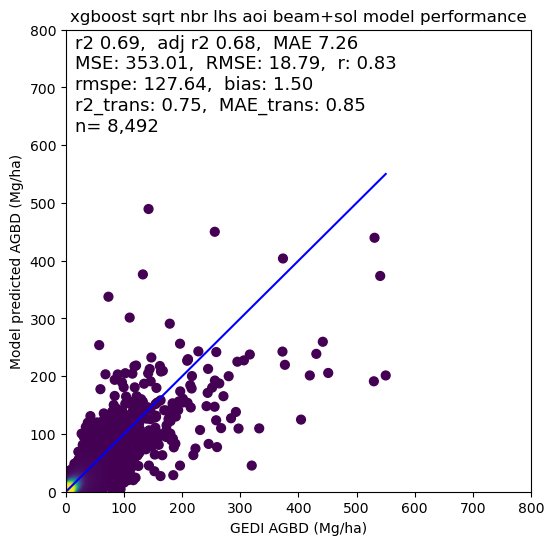

In [41]:
svi = list(range(6,54))+list(range(91,96))
print(np.array(ls_vars)[svi])
rfr6 =  xgb.XGBRegressor(colsample_bytree= 0.7,
                 learning_rate=0.01,
                 max_depth= 10,
                 min_child_weight= 5,
                 n_estimators= 800,
                 subsample= 0.7) 
rfr6.fit(X_train[:, svi], y_train)
y_hat = rfr6.predict(x_test[:, svi])
model_performance(y_test, y_hat,x_test[:, svi])

In [ ]:
hyperParameterTuning(X_train[:, svi], y_train, rfr6)  

['ftv_b1_fit_contrast' 'ftv_b1_fit_diss' 'ftv_b1_fit_savg'
 'ftv_b1_fit_idm' 'ftv_b1_fit_asm' 'ftv_b1_fit_ent' 'ftv_b1_fit_var'
 'ftv_b1_fit_corr' 'ftv_b2_fit_contrast' 'ftv_b2_fit_diss'
 'ftv_b2_fit_savg' 'ftv_b2_fit_idm' 'ftv_b2_fit_asm' 'ftv_b2_fit_ent'
 'ftv_b2_fit_var' 'ftv_b2_fit_corr' 'ftv_b3_fit_contrast'
 'ftv_b3_fit_diss' 'ftv_b3_fit_savg' 'ftv_b3_fit_idm' 'ftv_b3_fit_asm'
 'ftv_b3_fit_ent' 'ftv_b3_fit_var' 'ftv_b3_fit_corr' 'ftv_b4_fit_contrast'
 'ftv_b4_fit_diss' 'ftv_b4_fit_savg' 'ftv_b4_fit_idm' 'ftv_b4_fit_asm'
 'ftv_b4_fit_ent' 'ftv_b4_fit_var' 'ftv_b4_fit_corr' 'ftv_b5_fit_contrast'
 'ftv_b5_fit_diss' 'ftv_b5_fit_savg' 'ftv_b5_fit_idm' 'ftv_b5_fit_asm'
 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b5_fit_corr' 'ftv_b7_fit_contrast'
 'ftv_b7_fit_diss' 'ftv_b7_fit_savg' 'ftv_b7_fit_idm' 'ftv_b7_fit_asm'
 'ftv_b7_fit_ent' 'ftv_b7_fit_var' 'ftv_b7_fit_corr' 'slope' 'aspect'
 'dem' 'lon_lowestmode' 'lat_lowestmode']


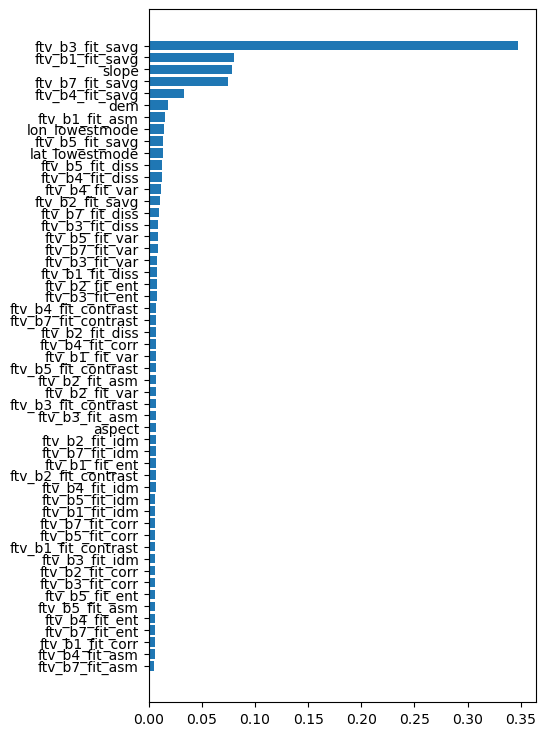

In [42]:
### plot the importance of the variables 
features = np.array(ls_vars)[svi]
print(features)
f_i = list(zip(features,rfr6.feature_importances_))
f_i.sort(key = lambda x : x[1])
plt.figure(figsize=(5, 9))
plt.barh([x[0] for x in f_i],[x[1] for x in f_i])

plt.show()

(42459, 53)
(42459, 53)
dropping covars: ['ftv_b1_fit_var' 'ftv_b2_fit_contrast' 'ftv_b2_fit_diss'
 'ftv_b2_fit_savg' 'ftv_b2_fit_asm' 'ftv_b2_fit_ent' 'ftv_b2_fit_var'
 'ftv_b3_fit_contrast' 'ftv_b3_fit_diss' 'ftv_b3_fit_savg'
 'ftv_b3_fit_asm' 'ftv_b3_fit_ent' 'ftv_b3_fit_var' 'ftv_b4_fit_contrast'
 'ftv_b4_fit_asm' 'ftv_b4_fit_ent' 'ftv_b4_fit_var' 'ftv_b5_fit_asm'
 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b7_fit_diss' 'ftv_b7_fit_savg'
 'ftv_b7_fit_asm' 'ftv_b7_fit_ent' 'ftv_b7_fit_var']
remaining number of vars 28 ['ftv_b1_fit_contrast' 'ftv_b1_fit_diss' 'ftv_b1_fit_savg'
 'ftv_b1_fit_idm' 'ftv_b1_fit_asm' 'ftv_b1_fit_ent' 'ftv_b1_fit_corr'
 'ftv_b2_fit_idm' 'ftv_b2_fit_corr' 'ftv_b3_fit_idm' 'ftv_b3_fit_corr'
 'ftv_b4_fit_diss' 'ftv_b4_fit_savg' 'ftv_b4_fit_idm' 'ftv_b4_fit_corr'
 'ftv_b5_fit_contrast' 'ftv_b5_fit_diss' 'ftv_b5_fit_savg'
 'ftv_b5_fit_idm' 'ftv_b5_fit_corr' 'ftv_b7_fit_contrast' 'ftv_b7_fit_idm'
 'ftv_b7_fit_corr' 'slope' 'aspect' 'dem' 'lon_lowestmode'
 'lat_lowest

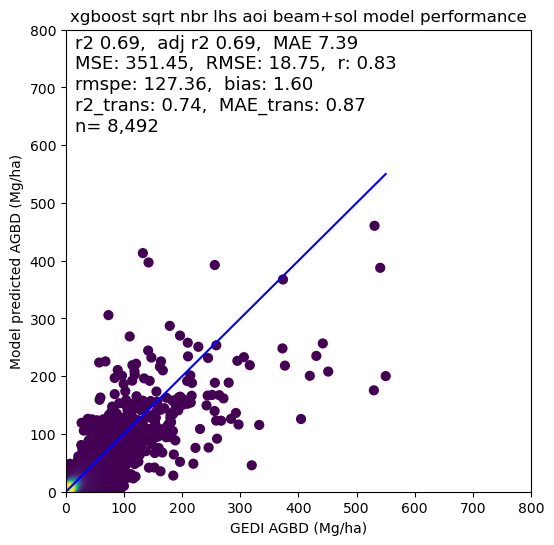

correction factor is:1.1865725608520583
1.1865725608520583


In [43]:
C= dcoll(svi, features,  save = None )
print(C)

#### 5) model with the best performing metrics from the above models 

[15, 61, 62, 77, 85, 91, 93, 95]


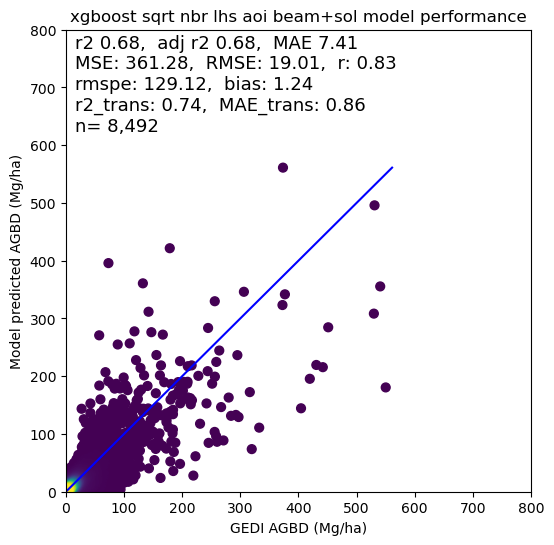

correction factor is:1.1553327531240387


In [44]:
tvars =['ftv_b2_fit_diss', 'ftv_ndvi_fit', 'ftv_evi_fit', 'ADVAL', 'BDVAL', 'slope','dem', 'lat_lowestmode']
tind= np.where(np.isin(ls_vars,tvars))[0].tolist()
print(tind)
svi =tind
rfr7 =  xgb.XGBRegressor() 
rfr7.fit(X_train[:, svi], y_train)
y_hat = rfr7.predict(x_test[:, svi])
model_performance(y_test, y_hat,x_test[:, svi])#, save='rfr7_var10_ori')

#calculating the correction fcator C for transformed data 
C = np.average(np.square(y_train))/np.average(np.square(y_hat))
print('correction factor is:'+str(C))

(42459, 8)
(42459, 8)
dropping covars: []
remaining number of vars 8 ['ftv_b2_fit_diss' 'ftv_ndvi_fit' 'ftv_evi_fit' 'ADVAL' 'BDVAL' 'slope'
 'dem' 'lat_lowestmode']


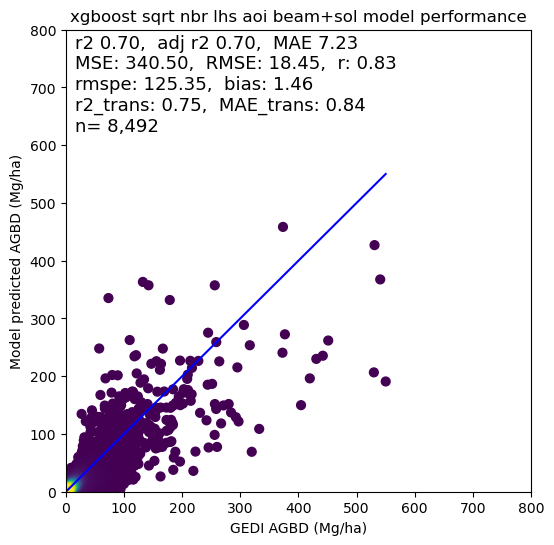

correction factor is:1.174700922556168


In [46]:
C= dcoll(tind, np.array(tvars),save =None)

### Candidate model for the tile

[7, 19, 20, 22, 23, 24, 26, 28, 29, 31, 35, 36, 37, 38, 39, 40, 43, 44, 46, 47, 52, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 74, 75, 77, 78, 79, 82, 84, 85, 86, 88, 89, 91, 92, 93, 94, 95]
(42459, 55)
(42459, 55)
dropping covars: ['ftv_b3_fit_contrast' 'ftv_b3_fit_diss' 'ftv_b3_fit_var' 'ftv_b4_fit_ent'
 'ftv_b4_fit_var' 'ftv_b5_fit_ent' 'ftv_b5_fit_var' 'ftv_b7_fit_diss'
 'ftv_b7_fit_var' 'Shade' 'ftv_nbr_fit' 'ftv_ndfi_fit' 'ftv_ndvi_fit'
 'ftv_ndmi_fit' 'ftv_b2_fit' 'ftv_b3_fit' 'ftv_b5_fit' 'ftv_b7_fit'
 'ftv_tcw_fit' 'ftv_tcb_fit' 'ftv_tca_fit' 'ADVAL' 'ADVA5' 'BDROC']
remaining number of vars 31 ['ftv_b1_fit_diss' 'ftv_b2_fit_ent' 'ftv_b2_fit_var' 'ftv_b3_fit_savg'
 'ftv_b3_fit_asm' 'ftv_b3_fit_corr' 'ftv_b4_fit_diss' 'ftv_b4_fit_corr'
 'ftv_b5_fit_contrast' 'ftv_b5_fit_diss' 'ftv_b5_fit_savg'
 'ftv_b7_fit_contrast' 'NPV' 'Soil' 'NDFI' 'ftv_evi_fit' 'ftv_ndsi_fit'
 'ftv_b1_fit' 'ftv_b4_fit' 'ADDUR' 'ADROC' 'ADRE' 'BDMAG' 'BDVAL' 'LMDUR'
 'LMMAG' 'sl

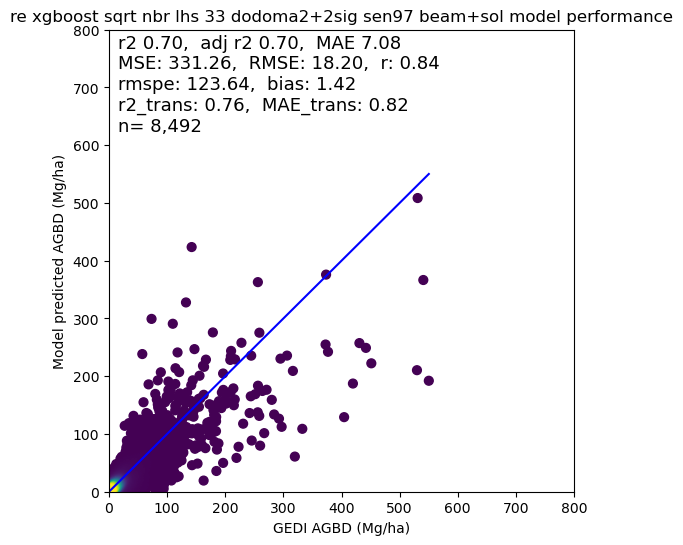

correction factor is:1.1712043131876653


In [46]:
# check collinearity among features 
features = np.array(ls_vars)[selection.get_support()]  #if the best model is the seletcion_model 
tind= np.where(np.isin(ls_vars,features))[0].tolist()
print(tind)
svi = tind

# features= tvars
select_vars = np.array(features)
select_x= x[:, svi] #x[:, selection.get_support()]
print(select_x.shape)
select_x_df = pd.DataFrame(data=select_x[0:,0:],    # values
                           index = select_x[0:,0], # 1st column as index
                           columns=select_vars)
print(select_x_df.shape)
#--------------dropping highly correlated features---------------------------
# Create correlation matrix
corr_matrix = select_x_df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

# Find features with correlation greater than 0.90
to_drop = np.array([column for column in upper.columns if any(upper[column] > 0.90)])
# print(type(to_drop))
print("dropping covars:", to_drop)
# to_drop.remove('ftv_tcb_fit')
td= np.where(np.isin(select_x_df.columns,to_drop))
td_bool = np.array([True for i in range(select_x_df.shape[1])])
# print(td_bool[td])
td_bool[td]=False
# print(td_bool)
print('remaining number of vars', len(select_vars[td_bool]), select_vars[td_bool])
#get the index of the the to-drop features
coll_rm=xgb.XGBRegressor(colsample_bytree= 0.7,
         learning_rate= 0.01,
         max_depth= 10,
         min_child_weight= 5,
         n_estimators= 800,
         subsample= 0.7)
coll_rm.fit(X_train[:, svi][:, td_bool], y_train)

y_hat = coll_rm.predict(x_test[:, svi][:, td_bool])
model_performance(y_test, y_hat, x_test[:, svi][:, td_bool])#, save='collrm_decol')

C = np.average(back_trans(y_train))/np.average(back_trans(y_hat))
print('correction factor is:'+str(C))

In [47]:
#update the svi with correlated vars dropped
svi = np.array(svi)[td_bool]
features = select_vars[td_bool]
print(svi.shape)

(31,)


## Tune the hyperparamters on the thresholding model (selection_model) and the optimal model

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import timeit

In [49]:
#use these parameters for updating the corresponding models above
tic=timeit.default_timer()
print(hyperParameterTuning(X_train[:, svi], y_train, coll_rm))  
toc=timeit.default_timer()
print(toc-tic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.5, 'objective': 'reg:squarederror', 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
17495.66052714805


# CV for the best performing model above

In [111]:
coll_rm=rfr7

In [299]:
from sklearn.model_selection import cross_val_predict, cross_val_score
tic=timeit.default_timer()
validation_result = cross_val_score(coll_rm, x[:, svi], y, cv=10, scoring = 'neg_mean_squared_error',n_jobs=-1)
print(np.sqrt(np.abs(validation_result)))
print(np.mean(np.sqrt(np.abs(validation_result))))
toc=timeit.default_timer()
print(toc-tic)

[1.23380141 1.25608536 1.32968211 1.21595773 1.24070078 1.32031976
 1.29266746 1.25947918 1.32194452 1.28679619]
1.2757434501920721
99.80261939298362


158.54127656295896
saving fig


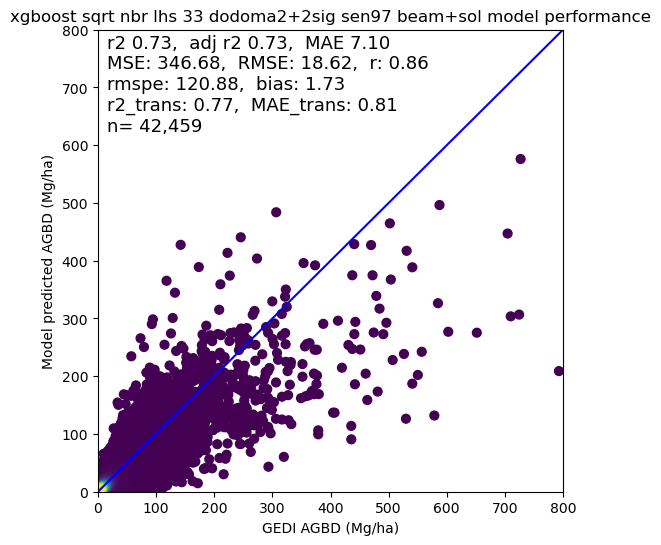

In [303]:
tic=timeit.default_timer()
cv_estimations = cross_val_predict(coll_rm, x[:, svi], y, cv=10,n_jobs=-1)
toc=timeit.default_timer()
print(toc-tic)
model_performance(y, cv_estimations, x_test[:, svi], save =None)

### Export the model for applictaion across time

In [48]:
#confirm model name
print(pattern)

re_xgboost_sqrt_nbr_lhs_33_dodoma2+2sig_sen97_beam+sol


In [49]:
coll_rm= coll_rm

In [50]:
mdir ='agbd_predictions/tileX_model_out/model_obj/'
filename = mdir+pattern+'_model.sav'
print(filename)

agbd_predictions/rev_dodoma_ts_out/model_obj/re_xgboost_sqrt_nbr_lhs_33_dodoma2+2sig_sen97_beam+sol_nbr_model.sav


In [51]:
import joblib
joblib.dump(coll_rm, filename)

['agbd_predictions/rev_dodoma_ts_out/model_obj/re_xgboost_sqrt_nbr_lhs_33_dodoma2+2sig_sen97_beam+sol_nbr_model.sav']

In [52]:
print(C)

1.1712043131876653


In [53]:
np.savetxt(mdir+pattern+'_nbr_model_C.csv', np.array([C]), delimiter=",")

In [54]:
print(features)

['ftv_b1_fit_diss' 'ftv_b2_fit_ent' 'ftv_b2_fit_var' 'ftv_b3_fit_savg'
 'ftv_b3_fit_asm' 'ftv_b3_fit_corr' 'ftv_b4_fit_diss' 'ftv_b4_fit_corr'
 'ftv_b5_fit_contrast' 'ftv_b5_fit_diss' 'ftv_b5_fit_savg'
 'ftv_b7_fit_contrast' 'NPV' 'Soil' 'NDFI' 'ftv_evi_fit' 'ftv_ndsi_fit'
 'ftv_b1_fit' 'ftv_b4_fit' 'ADDUR' 'ADROC' 'ADRE' 'BDMAG' 'BDVAL' 'LMDUR'
 'LMMAG' 'slope' 'aspect' 'dem' 'lon_lowestmode' 'lat_lowestmode']


In [55]:
len(features)

31

In [56]:
df = pd.DataFrame(features)
df.to_csv(mdir+pattern+'_nbr_model_Features.csv',header=False, index=False)

In [57]:
df.shape

(31, 1)

In [58]:
samp_df_geo.agbd.to_csv(mdir+pattern+'_nbr_model_train_response_var.csv',header=False, index=False)

In [59]:
samp_df_geo.agbd.shape

(42459,)

In [60]:
samp_df_geo.agbd_se.to_csv(mdir+pattern+'_nbr_model_train_response_se.csv',header=False, index=False)

In [61]:
np.save(mdir+pattern+'_nbr_model_train_alltraining.npy', x[:, svi])

In [62]:
x[:, svi].shape

(42459, 31)

In [63]:
samp_df_geo.shape

(42459, 112)

In [64]:
coll_rm

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.7, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.01, max_delta_step=0,
             max_depth=10, min_child_weight=5, missing=nan,
             monotone_constraints='()', n_estimators=800, n_jobs=20,
             num_parallel_tree=1, objective='reg:squarederror',
             predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
             scale_pos_weight=1, subsample=0.7, tree_method='exact',
             validate_parameters=1, verbosity=None)